In [1]:
"""Building thermal simulation with thermostat setpoint control.

This notebook-style script demonstrates the SBSim building simulator
with HVAC thermostat setpoint control for a two-zone office building.
It runs a winter heating and a summer cooling scenario, each for 7 days,
and produces visualisations of zone temperatures, HVAC energy, occupancy,
and floor-plan spatial heatmaps.

Run with:
    poetry run python smart_control/notebooks/building_setpoint_control_demo.py

Convert to Jupyter notebook with:
    poetry run jupytext --to notebook \
        smart_control/notebooks/building_setpoint_control_demo.py
"""

'Building thermal simulation with thermostat setpoint control.\n\nThis notebook-style script demonstrates the SBSim building simulator\nwith HVAC thermostat setpoint control for a two-zone office building.\nIt runs a winter heating and a summer cooling scenario, each for 7 days,\nand produces visualisations of zone temperatures, HVAC energy, occupancy,\nand floor-plan spatial heatmaps.\n\nRun with:\n    poetry run python smart_control/notebooks/building_setpoint_control_demo.py\n\nConvert to Jupyter notebook with:\n    poetry run jupytext --to notebook         smart_control/notebooks/building_setpoint_control_demo.py\n'

# Building Thermal Simulation with Thermostat Setpoint Control

This notebook demonstrates how the **SBSim** building simulator models
HVAC thermostat setpoint control for a simple two-zone office building.

## What you will see
1. A hard-coded 2-zone floor plan (23 × 12 control-volume grid)
2. Realistic material properties, HVAC devices, and occupancy schedule
3. A **winter heating** scenario – the building starts cold (275 K) and the
   boiler + VAVs warm it up to the comfort band
4. A **summer cooling** scenario – the building starts hot (310 K) and the
   air handler cools it back into the comfort band
5. Rich visualisations: zone temperature timeseries, HVAC energy rates,
   occupancy schedule, and spatial floor-plan heatmaps

## Architecture recap
```
WeatherController → SimulatorFlexibleGeometries.step_sim()
    ├─ finite_differences_timestep()   (conduction + convection)
    └─ per zone:
        VAV.output(zone_temp, supply_air_temp)
          ├─ if T < heating_sp → Boiler adds heat
          └─ if T > cooling_sp → AirHandler removes heat
            └─ building.apply_thermal_power_zone(zone, q_zone)
```

## Section 0 – Imports

In [2]:
# Standard library
import copy
import os
import sys

# Numeric / plotting
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make sure the repo root is on the path so simulator modules are importable.
# In a Jupyter notebook __file__ is not defined; we fall back to cwd which
# should be the repo root when launching jupyter from the repo directory.
try:
  _nb_dir = os.path.dirname(os.path.abspath(__file__))
  REPO_ROOT = os.path.abspath(os.path.join(_nb_dir, "..", ".."))
except NameError:
  REPO_ROOT = os.path.abspath(os.getcwd())

if REPO_ROOT not in sys.path:
  sys.path.insert(0, REPO_ROOT)

# SBSim simulator modules  (placed after sys.path setup – necessary for
# notebooks that set the path at runtime)
# pylint: disable=wrong-import-position
from smart_control.simulator import air_handler as air_handler_py
from smart_control.simulator import boiler as boiler_py
from smart_control.simulator import building as building_py
from smart_control.simulator import hvac_floorplan_based as floorplan_hvac_py
from smart_control.simulator import setpoint_schedule as setpoint_schedule_py
from smart_control.simulator import step_function_occupancy as occupancy_py
from smart_control.simulator import weather_controller as weather_controller_py

# pylint: enable=wrong-import-position

# Convenience constant
KELVIN_TO_CELSIUS = 273.15

print("All imports OK.")
print(
    f"NumPy {np.__version__}, "
    f"Pandas {pd.__version__}, "
    f"Matplotlib {matplotlib.__version__}"
)

All imports OK.
NumPy 1.26.4, Pandas 2.3.0, Matplotlib 3.10.3


## Section 1 – Floor Plan Definition and Visualisation

The floor plan is a 2-D NumPy integer array where each cell encodes its type:

| Code | Type |
|------|------|
| `0`  | Interior air (room space) |
| `1`  | Interior wall / corridor |
| `2`  | Exterior wall |

This is exactly `_create_dummy_floor_plan_small()` from the test suite.
It has **two rooms** separated by a horizontal corridor wall at row 11.

In [3]:
# ── Hard-coded floor plan (23 rows × 12 cols) ────────────────────────────────
# Taken verbatim from
# FlexibleFloorplanSimulatorTest._create_dummy_floor_plan_small()
FLOOR_PLAN = np.array([
    [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],  # row  0  exterior top
    [2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2],  # row  1  corridor
    [2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2],  # row  2  corridor
    [2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2],  # row  3  room_1
    [2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2],
    [2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2],
    [2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2],
    [2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2],
    [2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2],
    [2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2],
    [2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2],  # row 10  room_1 last air row
    [2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2],  # row 11  interior corridor wall
    [2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2],  # row 12  room_2
    [2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2],
    [2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2],
    [2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2],
    [2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2],
    [2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2],
    [2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2],
    [2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2],  # row 19  room_2 last air row
    [2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2],  # row 20  corridor
    [2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2],  # row 21  corridor
    [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],  # row 22  exterior bottom
])

print(f"Floor plan shape: {FLOOR_PLAN.shape}  (rows × cols)")
print(f"Air cells  (code 0): {(FLOOR_PLAN == 0).sum()}")
print(f"Wall cells (code 1): {(FLOOR_PLAN == 1).sum()}")
print(f"Ext. cells (code 2): {(FLOOR_PLAN == 2).sum()}")

Floor plan shape: (23, 12)  (rows × cols)
Air cells  (code 0): 96
Wall cells (code 1): 114
Ext. cells (code 2): 66


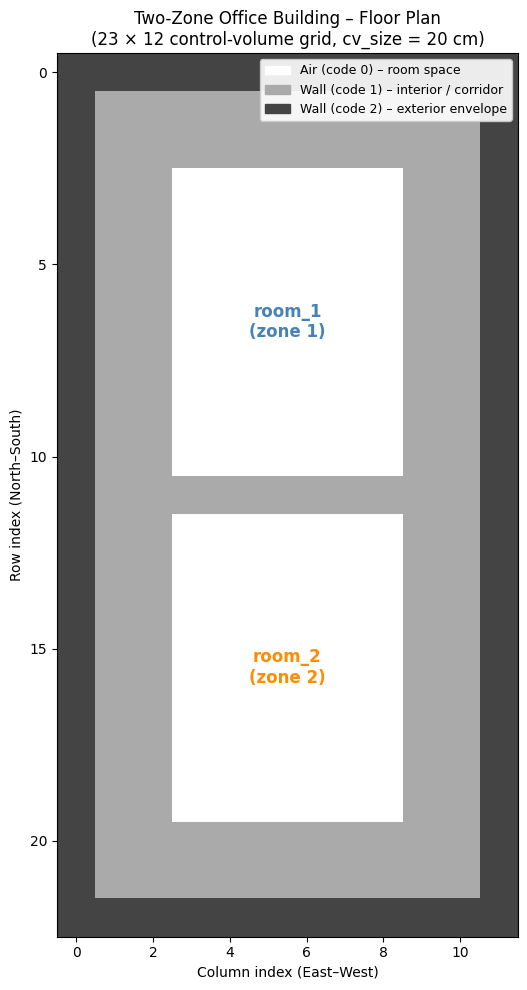

In [4]:
# ── Visualise the floor plan ──────────────────────────────────────────────────
fig_fp, ax_fp = plt.subplots(figsize=(7, 10))

# Custom discrete colormap: exterior=charcoal, interior wall=silver, air=white
cmap_fp = mcolors.ListedColormap(["white", "#aaaaaa", "#444444"])
bounds_fp = [-0.5, 0.5, 1.5, 2.5]
norm_fp = mcolors.BoundaryNorm(bounds_fp, cmap_fp.N)

ax_fp.imshow(
    FLOOR_PLAN, cmap=cmap_fp, norm=norm_fp, origin="upper", aspect="equal"
)

# Annotate zones
ax_fp.text(
    5.5,
    6.5,
    "room_1\n(zone 1)",
    ha="center",
    va="center",
    fontsize=12,
    color="steelblue",
    fontweight="bold",
)
ax_fp.text(
    5.5,
    15.5,
    "room_2\n(zone 2)",
    ha="center",
    va="center",
    fontsize=12,
    color="darkorange",
    fontweight="bold",
)

# Legend
legend_patches = [
    mpatches.Patch(color="white", label="Air (code 0) – room space"),
    mpatches.Patch(
        color="#aaaaaa", label="Wall (code 1) – interior / corridor"
    ),
    mpatches.Patch(color="#444444", label="Wall (code 2) – exterior envelope"),
]
ax_fp.legend(
    handles=legend_patches, loc="upper right", fontsize=9, framealpha=0.9
)

ax_fp.set_title(
    "Two-Zone Office Building – Floor Plan\n"
    "(23 × 12 control-volume grid, cv_size = 20 cm)",
    fontsize=12,
)
ax_fp.set_xlabel("Column index (East–West)")
ax_fp.set_ylabel("Row index (North–South)")
plt.tight_layout()
plt.show()

## Section 2 – Building Construction & HVAC Sizing

### Material properties

We use the **default** material properties from `building.py` so that the
building envelope responds realistically to weather:

| Layer | Conductivity (W/m·K) | Heat cap (J/kg·K) | Density (kg/m³) | Source |
|-------|---------------------|-------------------|-----------------|--------|
| Air   | 50.0 (effective)    | 700               | 1.2             | `DefaultInsideAirMaterialProperties` |
| Int. wall | 2.0             | 1 000             | 1 800           | `DefaultInsideWallMaterialProperties` |
| Ext. wall | 0.05            | 1 000             | 3 000           | `DefaultExteriorWallMaterialProperties` |

### Building geometry (from floor plan)

- **Air cells** (code 0): 96 CVs → each 0.20 m × 0.20 m → floor area
  = 96 × 0.04 = 3.84 m²
- **Floor height**: 3.0 m → building volume = 3.84 × 3.0 = 11.52 m³
- **Exterior perimeter** (code 2): top row 12 + bottom row 12 +
  left col 23 + right col 23 − 4 corners = 66 CVs →
  envelope area ≈ 66 × 0.20 × 3.0 = 39.6 m²

### Rule-of-thumb HVAC sizing

Peak envelope heat loss (winter, ΔT = 25 K):

$$Q_{loss} = U \times A_{env} \times \Delta T$$

With exterior conductivity k = 0.05 W/m·K and wall thickness
= 2 × 0.20 m = 0.40 m (two layers of exterior CV):

$$U = k / d = 0.05 / 0.40 = 0.125\ \text{W/m²·K}$$
$$Q_{loss} = 0.125 \times 39.6 \times 25 \approx 124\ \text{W}$$

But we also need to overcome the **thermal mass** of interior walls
(≈ 168 wall CVs × 0.04 m² × 3.0 m × 1800 kg/m³ × 1000 J/kg·K)
during warm-up.  We size the HVAC at **~10× steady-state** to get
reasonable warm-up / cool-down within a few hours:

$$Q_{HVAC,design} \approx 2{-}5\ \text{kW per zone}$$

In [5]:
# ── Shared building parameters ────────────────────────────────────────────────
CV_SIZE_CM = 20.0  # control-volume side length [cm]
FLOOR_HEIGHT_CM = 300.0  # floor-to-ceiling height [cm]

# Use DEFAULT material properties from building.py
inside_air_props = building_py.DefaultInsideAirMaterialProperties()
inside_wall_props = building_py.DefaultInsideWallMaterialProperties()
building_exterior_props = building_py.DefaultExteriorWallMaterialProperties()

print("=== Material Properties ===")
for label, props in [
    ("Air", inside_air_props),
    ("Interior wall", inside_wall_props),
    ("Exterior wall", building_exterior_props),
]:
  print(
      f"  {label:15s}: k={props.conductivity:.2f} W/m·K, "
      f"c={props.heat_capacity:.0f} J/kg·K, "
      f"ρ={props.density:.0f} kg/m³"
  )


def create_building(
    initial_temp_k: float,
) -> building_py.FloorPlanBasedBuilding:
  """Construct a FloorPlanBasedBuilding at the given initial temperature."""
  zone_map = copy.deepcopy(FLOOR_PLAN)
  return building_py.FloorPlanBasedBuilding(
      cv_size_cm=CV_SIZE_CM,
      floor_height_cm=FLOOR_HEIGHT_CM,
      initial_temp=initial_temp_k,
      inside_air_properties=inside_air_props,
      inside_wall_properties=inside_wall_props,
      building_exterior_properties=building_exterior_props,
      floor_plan=FLOOR_PLAN,
      zone_map=zone_map,
      buffer_from_walls=0,
  )


# Quick smoke-test
_bld_test = create_building(293.0)
ROOM_ZONES = sorted(_bld_test.get_zone_average_temps())
print(f"\nActual room zones     : {ROOM_ZONES}")
print(f"Temperature grid shape: {_bld_test.temp.shape}")
print(f"Initial zone temps (K): {_bld_test.get_zone_average_temps()}")

# ── HVAC sizing calculations ─────────────────────────────────────────────────
N_AIR_CELLS = int((FLOOR_PLAN == 0).sum())
N_ZONES = len(ROOM_ZONES)
CV_SIZE_M = CV_SIZE_CM / 100.0
FLOOR_HEIGHT_M = FLOOR_HEIGHT_CM / 100.0
FLOOR_AREA_M2 = N_AIR_CELLS * CV_SIZE_M * CV_SIZE_M
BUILDING_VOLUME_M3 = FLOOR_AREA_M2 * FLOOR_HEIGHT_M

# Exterior wall envelope area (code-2 cells form a perimeter rectangle)
N_EXT_CELLS = int((FLOOR_PLAN == 2).sum())
ENVELOPE_AREA_M2 = N_EXT_CELLS * CV_SIZE_M * FLOOR_HEIGHT_M

# U-value of exterior wall (2 CV layers thick)
EXT_WALL_THICKNESS_M = 2.0 * CV_SIZE_M  # enlarged exterior = 2 layers
U_WALL = building_exterior_props.conductivity / EXT_WALL_THICKNESS_M

# Design ΔT
DESIGN_DT_HEATING = 25.0  # K (indoor 20°C, outdoor -5°C)
DESIGN_DT_COOLING = 15.0  # K (indoor 22°C, outdoor 37°C)

Q_LOSS_HEATING_W = U_WALL * ENVELOPE_AREA_M2 * DESIGN_DT_HEATING
Q_LOSS_COOLING_W = U_WALL * ENVELOPE_AREA_M2 * DESIGN_DT_COOLING

# Oversize factor to handle thermal mass warm-up/cool-down
OVERSIZE_FACTOR = 15.0
Q_DESIGN_HEATING_W = Q_LOSS_HEATING_W * OVERSIZE_FACTOR
Q_DESIGN_COOLING_W = Q_LOSS_COOLING_W * OVERSIZE_FACTOR

print("\n=== HVAC Sizing ===")
print(f"  Air cells: {N_AIR_CELLS}, Zones: {N_ZONES}")
print(f"  Floor area: {FLOOR_AREA_M2:.2f} m²")
print(f"  Building volume: {BUILDING_VOLUME_M3:.2f} m³")
print(
    f"  Exterior CVs: {N_EXT_CELLS}, Envelope area: {ENVELOPE_AREA_M2:.1f} m²"
)
print(f"  Ext. wall thickness: {EXT_WALL_THICKNESS_M:.2f} m")
print(f"  U_wall: {U_WALL:.4f} W/m²·K")
print(
    f"  Steady-state heat loss (ΔT={DESIGN_DT_HEATING}K): "
    f"{Q_LOSS_HEATING_W:.0f} W"
)
print(
    f"  Design heating capacity ({OVERSIZE_FACTOR}×): "
    f"{Q_DESIGN_HEATING_W:.0f} W = {Q_DESIGN_HEATING_W/1000:.1f} kW"
)
print(
    f"  Design cooling capacity ({OVERSIZE_FACTOR}×): "
    f"{Q_DESIGN_COOLING_W:.0f} W = {Q_DESIGN_COOLING_W/1000:.1f} kW"
)

# Diffuser check
print(f"\n=== Diffuser Check ===")
print(f"  Diffuser sum: {_bld_test.diffusers.sum():.3f}")
print(f"  Non-zero diffuser cells: {(_bld_test.diffusers > 0).sum()}")
for z in ROOM_ZONES:
  zone_coords = _bld_test._room_dict[z]  # pylint: disable=protected-access
  diff_sum = sum(
      _bld_test.diffusers[c] for c in zone_coords if _bld_test.diffusers[c] > 0
  )
  n_diff = sum(1 for c in zone_coords if _bld_test.diffusers[c] > 0)
  print(f"  {z}: {n_diff} diffusers, weight sum = {diff_sum:.4f}")

=== Material Properties ===
  Air            : k=50.00 W/m·K, c=700 J/kg·K, ρ=1 kg/m³
  Interior wall  : k=2.00 W/m·K, c=1000 J/kg·K, ρ=1800 kg/m³
  Exterior wall  : k=0.05 W/m·K, c=1000 J/kg·K, ρ=3000 kg/m³

Actual room zones     : ['room_1', 'room_2']
Temperature grid shape: (23, 12)
Initial zone temps (K): {'room_1': 293.0, 'room_2': 293.0}

=== HVAC Sizing ===
  Air cells: 96, Zones: 2
  Floor area: 3.84 m²
  Building volume: 11.52 m³
  Exterior CVs: 66, Envelope area: 39.6 m²
  Ext. wall thickness: 0.40 m
  U_wall: 0.1250 W/m²·K
  Steady-state heat loss (ΔT=25.0K): 124 W
  Design heating capacity (15.0×): 1856 W = 1.9 kW
  Design cooling capacity (15.0×): 1114 W = 1.1 kW

=== Diffuser Check ===
  Diffuser sum: 2.000
  Non-zero diffuser cells: 2
  room_1: 1 diffusers, weight sum = 1.0000
  room_2: 1 diffusers, weight sum = 1.0000


/home/ecosang/sbsim/smart_control/simulator/building_utils.py:268: UserWarning: Connected components is showing that there are 4 or fewer
     rooms in your building. You may have your 0's and 1's inverted in the
     floor_plan. Remember that for the connectedComponents function,
     0's must code for exterior space and exterior or interior walls,
     and 1's must code for interior space.
  warnings.warn("""Connected components is showing that there are 4 or fewer


## Section 3 – HVAC Configuration (sized to building)

### HVAC hierarchy
```
FloorPlanBasedHvac
├── Boiler        – hot water loop for VAV reheat
├── AirHandler    – mixed / conditioned supply air
└── VAV × N zones – variable-air-volume with thermostat
      └── SetpointSchedule – comfort (9am–6pm) vs eco
```

### Sizing approach

From Section 2 we computed the design heating load.  The VAV delivers
heat to each zone via:

$$q_{zone} = \dot{m}_{air} \cdot c_{air} \cdot (T_{supply} - T_{zone})$$

The simulator treats `max_air_flow_rate` as volumetric (m³/s) and
multiplies by `AIR_HEAT_CAPACITY = 1006 J/kg·K` directly (i.e. assumes
ρ ≈ 1 kg/m³ implicitly).  We size the VAV air and water flows so that
the per-zone capacity ≈ `Q_DESIGN_HEATING_W / N_ZONES`.

| Device | Parameter | Value | Rationale |
|--------|-----------|-------|-----------|
| Boiler | `reheat_water_setpoint` | 350 K (77 °C) | Standard HW |
| AHU | `heating_air_temp_setpoint` | 292 K | Min supply air |
| AHU | `cooling_air_temp_setpoint` | 300 K | Max supply air |
| AHU | `recirculation` | 0.3 | 30 % return air |
| AHU | `max_air_flow_rate` | 2.0 m³/s | Building total |
| VAV | `max_air_flow_rate` | 0.50 m³/s | Per zone |
| VAV | `reheat_max_water_flow_rate` | 0.10 kg/s | Per zone |

In [6]:
# ── Setpoint schedule ─────────────────────────────────────────────────────────
HEATING_SETPOINT_K = 292.0  # 18.85 °C  comfort heating
COOLING_SETPOINT_K = 297.0  # 23.85 °C  comfort cooling
ECO_LOW_K = 288.0  # 14.85 °C  eco / setback
ECO_HIGH_K = 300.0  # 26.85 °C  eco / setback

# ── Properly-sized HVAC parameters ───────────────────────────────────────────
BOILER_SUPPLY_WATER_SP_K = 350.0  # 77 °C
BOILER_PUMP_HEAD = 3.0  # [m]
BOILER_PUMP_EFFICIENCY = 0.6
AHU_RECIRCULATION = 0.3  # 30% return air → more outdoor air for cooling
AHU_HEAT_SP_K = 292.0  # mixed supply air heating SP [K]
AHU_COOL_SP_K = 300.0  # mixed supply air cooling SP [K]
AHU_FAN_PRESSURE = 500.0  # [Pa] realistic duct static pressure
AHU_FAN_EFFICIENCY = 0.8
AHU_MAX_AIR_FLOW = 2.0  # [m³/s] total building capacity

# Per-zone VAV sizing
# q_zone = air_flow * C_air * (T_supply - T_zone) + water contribution
# With air=0.5, C_air=1006, ΔT≈20K → q ≈ 0.5*1006*20 = 10,060 W ≈ 10 kW
# With water=0.10, C_water=4180, ΔT_water≈60K → additional 25 kW capacity
VAV_MAX_AIR_FLOW = 0.50  # [m³/s] per zone
VAV_MAX_WATER_FLOW = 0.10  # [kg/s] per zone hot water


def create_hvac(zone_identifiers) -> floorplan_hvac_py.FloorPlanBasedHvac:
  """Build a fresh HVAC object wired to the given zone identifiers."""
  new_boiler = boiler_py.Boiler(
      reheat_water_setpoint=BOILER_SUPPLY_WATER_SP_K,
      water_pump_differential_head=BOILER_PUMP_HEAD,
      water_pump_efficiency=BOILER_PUMP_EFFICIENCY,
      device_id="boiler_id",
  )
  # Fix: initialise return_water_temperature_sensor to ~supply setpoint
  # instead of default 0 K to avoid artefact at step 0.
  new_boiler.return_water_temperature_sensor = BOILER_SUPPLY_WATER_SP_K

  return floorplan_hvac_py.FloorPlanBasedHvac(
      zone_identifier=zone_identifiers,
      air_handler=air_handler_py.AirHandler(
          recirculation=AHU_RECIRCULATION,
          heating_air_temp_setpoint=AHU_HEAT_SP_K,
          cooling_air_temp_setpoint=AHU_COOL_SP_K,
          fan_differential_pressure=AHU_FAN_PRESSURE,
          fan_efficiency=AHU_FAN_EFFICIENCY,
          max_air_flow_rate=AHU_MAX_AIR_FLOW,
      ),
      boiler=new_boiler,
      schedule=setpoint_schedule_py.SetpointSchedule(
          morning_start_hour=9,
          evening_start_hour=18,
          comfort_temp_window=(HEATING_SETPOINT_K, COOLING_SETPOINT_K),
          eco_temp_window=(ECO_LOW_K, ECO_HIGH_K),
          holidays={7, 223, 245},
      ),
      vav_max_air_flow_rate=VAV_MAX_AIR_FLOW,
      vav_reheat_max_water_flow_rate=VAV_MAX_WATER_FLOW,
  )


# ── Sanity check: expected zone supply temperature in HEAT mode ──────────────
print("=== HVAC Sanity Check ===")
ahu_supply_approx = AHU_HEAT_SP_K
c_air_flow = 1006 * VAV_MAX_AIR_FLOW
c_water_flow = 4180 * VAV_MAX_WATER_FLOW
zone_supply_est = (
    ahu_supply_approx * c_air_flow + BOILER_SUPPLY_WATER_SP_K * c_water_flow
) / (c_air_flow + c_water_flow)
q_heat_est = c_air_flow * (zone_supply_est - 275.0)  # from 275K start
print(f"  VAV_MAX_AIR_FLOW = {VAV_MAX_AIR_FLOW} m³/s per zone")
print(f"  VAV_MAX_WATER_FLOW = {VAV_MAX_WATER_FLOW} kg/s per zone")
print(
    f"  C_air×flow = {c_air_flow:.0f} W/K   "
    f"C_water×flow = {c_water_flow:.0f} W/K"
)
print(
    "  Expected zone supply temp (HEAT): "
    f"{zone_supply_est - KELVIN_TO_CELSIUS:.1f} °C"
)
print(f"  Estimated q_zone from 275K: {q_heat_est/1000:.1f} kW")

_hvac_test = create_hvac(ROOM_ZONES)
print(
    "  Boiler supply SP: "
    f"{_hvac_test.boiler.reheat_water_setpoint - KELVIN_TO_CELSIUS:.1f} °C"
)
print(
    "  Boiler init RW sensor: "
    f"{_hvac_test.boiler.return_water_temperature_sensor - KELVIN_TO_CELSIUS:.1f} °C"
)

=== HVAC Sanity Check ===
  VAV_MAX_AIR_FLOW = 0.5 m³/s per zone
  VAV_MAX_WATER_FLOW = 0.1 kg/s per zone
  C_air×flow = 503 W/K   C_water×flow = 418 W/K
  Expected zone supply temp (HEAT): 45.2 °C
  Estimated q_zone from 275K: 21.8 kW
  Boiler supply SP: 76.9 °C
  Boiler init RW sensor: -273.1 °C


## Section 4 – Weather Controller

* **Winter**: low = 268 K (−5 °C), high = 277 K (4 °C)
* **Summer**: low = 295 K (22 °C), high = 308 K (35 °C)

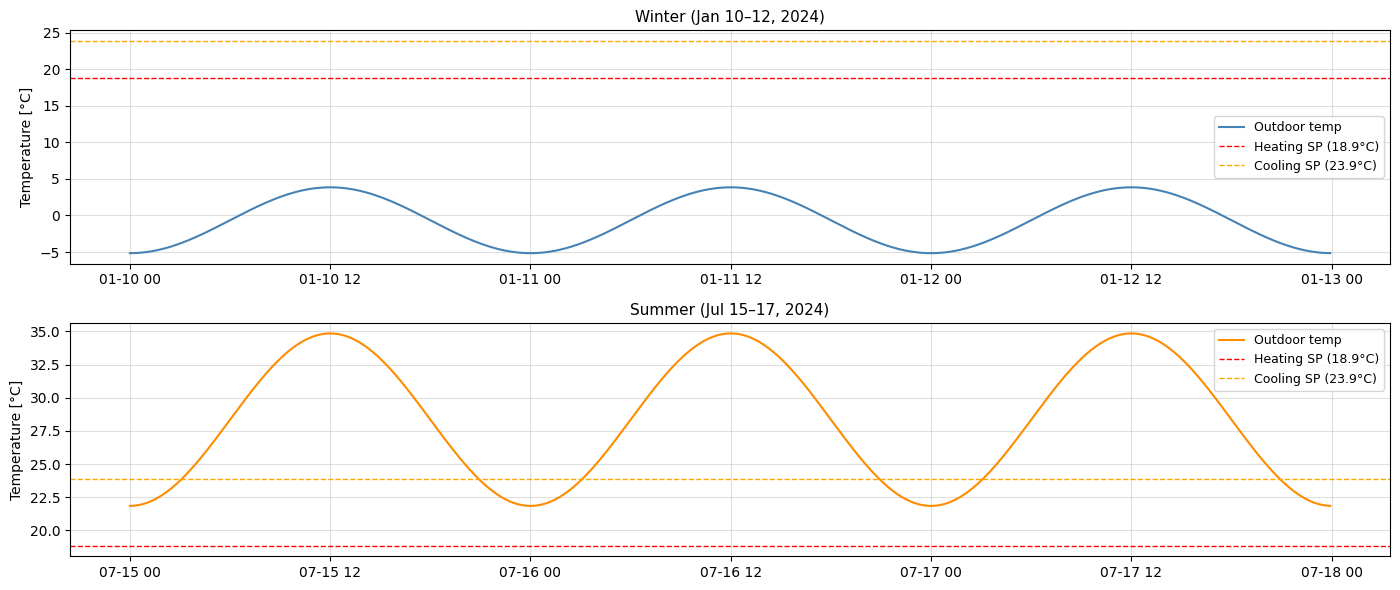

In [7]:
wc_winter = weather_controller_py.WeatherController(
    default_low_temp=268.0,
    default_high_temp=277.0,
    convection_coefficient=12.0,
)
wc_summer = weather_controller_py.WeatherController(
    default_low_temp=295.0,
    default_high_temp=308.0,
    convection_coefficient=12.0,
)

ts_range_w = pd.date_range("2024-01-10", periods=3 * 24 * 12, freq="5min")
winter_temps = [
    wc_winter.get_current_temp(t) - KELVIN_TO_CELSIUS for t in ts_range_w
]
ts_range_s = pd.date_range("2024-07-15", periods=3 * 24 * 12, freq="5min")
summer_temps = [
    wc_summer.get_current_temp(t) - KELVIN_TO_CELSIUS for t in ts_range_s
]

h_sp_c = HEATING_SETPOINT_K - KELVIN_TO_CELSIUS
c_sp_c = COOLING_SETPOINT_K - KELVIN_TO_CELSIUS

fig_wx, axes_wx = plt.subplots(2, 1, figsize=(14, 6), sharex=False)
for ax_wx, ts_rng, temps, colour, ttl in [
    (
        axes_wx[0],
        ts_range_w,
        winter_temps,
        "steelblue",
        "Winter (Jan 10–12, 2024)",
    ),
    (
        axes_wx[1],
        ts_range_s,
        summer_temps,
        "darkorange",
        "Summer (Jul 15–17, 2024)",
    ),
]:
  ax_wx.plot(ts_rng, temps, color=colour, lw=1.5, label="Outdoor temp")
  ax_wx.axhline(
      h_sp_c, color="red", ls="--", lw=1, label=f"Heating SP ({h_sp_c:.1f}°C)"
  )
  ax_wx.axhline(
      c_sp_c,
      color="orange",
      ls="--",
      lw=1,
      label=f"Cooling SP ({c_sp_c:.1f}°C)",
  )
  ax_wx.set_title(ttl, fontsize=11)
  ax_wx.set_ylabel("Temperature [°C]")
  ax_wx.legend(fontsize=9)
  ax_wx.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Section 5 – Occupancy Model

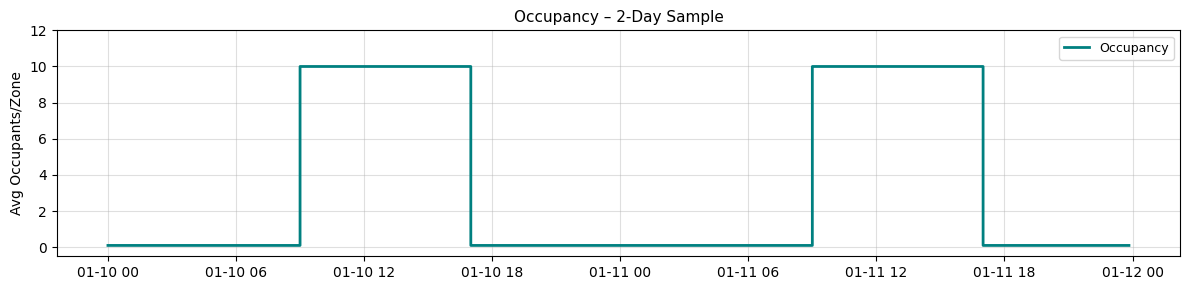

2026-04-28 11:45:53.111777: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-28 11:45:53.235402: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-28 11:45:53.235506: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-28 11:45:53.251646: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-28 11:45:53.305419: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-28 11:45:53.307213: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [8]:
occupancy = occupancy_py.StepFunctionOccupancy(
    work_start_time=pd.Timedelta(9, unit="h"),
    work_end_time=pd.Timedelta(17, unit="h"),
    work_occupancy=10.0,
    nonwork_occupancy=0.1,
)

occ_times = pd.date_range("2024-01-10", periods=2 * 24 * 12, freq="5min")
occ_vals = [
    occupancy.average_zone_occupancy("room_1", occ_times[i], occ_times[i + 1])
    for i in range(len(occ_times) - 1)
]

fig_occ, ax_occ = plt.subplots(figsize=(12, 3))
ax_occ.plot(
    occ_times[:-1],
    occ_vals,
    color="teal",
    lw=2,
    drawstyle="steps-post",
    label="Occupancy",
)
ax_occ.set_ylabel("Avg Occupants/Zone")
ax_occ.set_ylim(-0.5, 12)
ax_occ.set_title("Occupancy – 2-Day Sample", fontsize=11)
ax_occ.legend(fontsize=9)
ax_occ.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Also import TFSimulator
# pylint: disable=wrong-import-position
from smart_control.simulator import tf_simulator as tf_simulator_py

# pylint: enable=wrong-import-position

## Section 6 – TFSimulator: Heating Scenario (3-day)

3-day winter simulation with properly sized HVAC.  The 12-row debug
figure collects all key signals for diagnosing HVAC behaviour.

In [9]:
INITIAL_TEMP_HEATING = 275.0
START_TS_WINTER = pd.Timestamp("2024-01-10 00:00:00")
N_DAYS = 3
TIME_STEP_SEC = 300.0
N_STEPS = int(N_DAYS * 24 * 3600 / TIME_STEP_SEC)

bld_heat = create_building(INITIAL_TEMP_HEATING)
hvac_heat = create_hvac(sorted(bld_heat.get_zone_average_temps()))
ZONE_IDS = sorted(bld_heat.get_zone_average_temps())
REF_ZONE = ZONE_IDS[0]

sim_heat = tf_simulator_py.TFSimulator(
    building=bld_heat,
    hvac=hvac_heat,
    weather_controller=wc_winter,
    time_step_sec=TIME_STEP_SEC,
    convergence_threshold=0.1,
    iteration_limit=100,
    iteration_warning=10,
    start_timestamp=START_TS_WINTER,
)

print(
    "TFSimulator HEATING init. Mean zone T = "
    f"{bld_heat.temp.mean() - KELVIN_TO_CELSIUS:.2f} °C"
)
# ── Per-step data storage ────────────────────────────────────────────────────
ts_heat = []
zone_temp_h = {z: [] for z in ZONE_IDS}
h_sp_h, c_sp_h, mode_h = [], [], []
damper_h = {z: [] for z in ZONE_IDS}
reheat_v_h = {z: [] for z in ZONE_IDS}
zone_supply_temp_h = {z: [] for z in ZONE_IDS}
q_zone_h = {z: [] for z in ZONE_IDS}
ahu_supply_h = []
ahu_flow_h = []
boiler_sw_h = []
boiler_rw_h = []
boiler_gas_h = []
fan_elec_h = []
outdoor_h = []

for step in range(N_STEPS):
  ts = sim_heat.current_timestamp
  outdoor_k = wc_winter.get_current_temp(ts)
  rec_temp = bld_heat.temp.mean()
  ahu_supply_k = hvac_heat.air_handler.get_supply_air_temp(rec_temp, outdoor_k)

  ts_heat.append(ts)
  sched = hvac_heat.vavs[REF_ZONE].thermostat.get_setpoint_schedule()
  h_sp, c_sp = sched.get_temperature_window(ts)
  h_sp_h.append(h_sp)
  c_sp_h.append(c_sp)
  # pylint: disable=protected-access
  mode_h.append(hvac_heat.vavs[REF_ZONE].thermostat._current_mode.value)
  # pylint: enable=protected-access

  zone_avgs = bld_heat.get_zone_average_temps()
  for zid in ZONE_IDS:
    zone_temp_h[zid].append(zone_avgs[zid] - KELVIN_TO_CELSIUS)
    damper_h[zid].append(hvac_heat.vavs[zid].damper_setting)
    reheat_v_h[zid].append(hvac_heat.vavs[zid].reheat_valve_setting)
    zst_k = hvac_heat.vavs[zid].compute_zone_supply_temp(
        ahu_supply_k, hvac_heat.boiler.reheat_water_setpoint
    )
    zone_supply_temp_h[zid].append(zst_k - KELVIN_TO_CELSIUS)
    q_w = hvac_heat.vavs[zid].compute_energy_applied_to_zone(
        zone_avgs[zid], ahu_supply_k, hvac_heat.boiler.reheat_water_setpoint
    )
    q_zone_h[zid].append(q_w / 1000)

  ahu_supply_h.append(ahu_supply_k - KELVIN_TO_CELSIUS)
  ahu_flow_h.append(hvac_heat.air_handler.air_flow_rate)

  rw_k = hvac_heat.boiler.return_water_temperature_sensor
  boiler_sw_h.append(
      hvac_heat.boiler.supply_water_temperature_sensor - KELVIN_TO_CELSIUS
  )
  boiler_rw_h.append(rw_k - KELVIN_TO_CELSIUS)
  boiler_gas_h.append(
      hvac_heat.boiler.compute_thermal_energy_rate(rw_k, outdoor_k) / 1000
  )
  fan_elec_h.append(
      (
          hvac_heat.air_handler.compute_intake_fan_energy_rate()
          + hvac_heat.air_handler.compute_exhaust_fan_energy_rate()
      )
      / 1000
  )
  outdoor_h.append(outdoor_k - KELVIN_TO_CELSIUS)

  sim_heat.step_sim()

  if (step + 1) % 288 == 0:
    avg_t = sum(bld_heat.get_zone_average_temps().values()) / len(ZONE_IDS)
    print(
        f'  Day {(step+1)//288} | {ts.strftime("%m-%d %H:%M")}'
        f" | mean T={avg_t - KELVIN_TO_CELSIUS:.2f} °C"
        f" | outdoor={outdoor_k - KELVIN_TO_CELSIUS:.2f} °C"
        f" | mode={mode_h[-1]}"
    )

print("Heating simulation complete.")

/home/ecosang/sbsim/smart_control/simulator/building_utils.py:268: UserWarning: Connected components is showing that there are 4 or fewer
     rooms in your building. You may have your 0's and 1's inverted in the
     floor_plan. Remember that for the connectedComponents function,
     0's must code for exterior space and exterior or interior walls,
     and 1's must code for interior space.
  warnings.warn("""Connected components is showing that there are 4 or fewer
2026-04-28 11:45:55.597445: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-28 11:45:55.597945: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how t

TFSimulator HEATING init. Mean zone T = 1.85 °C


  Day 1 | 01-10 23:55 | mean T=16.92 °C | outdoor=-5.15 °C | mode=1


  Day 2 | 01-11 23:55 | mean T=16.92 °C | outdoor=-5.15 °C | mode=1


  Day 3 | 01-12 23:55 | mean T=16.92 °C | outdoor=-5.15 °C | mode=1
Heating simulation complete.


## Section 7 – Heating Scenario: 12-Row Debug Visualisation

Mode legend: 0 = OFF, 1 = HEAT, 2 = COOL, 3 = PASSIVE\_COOL

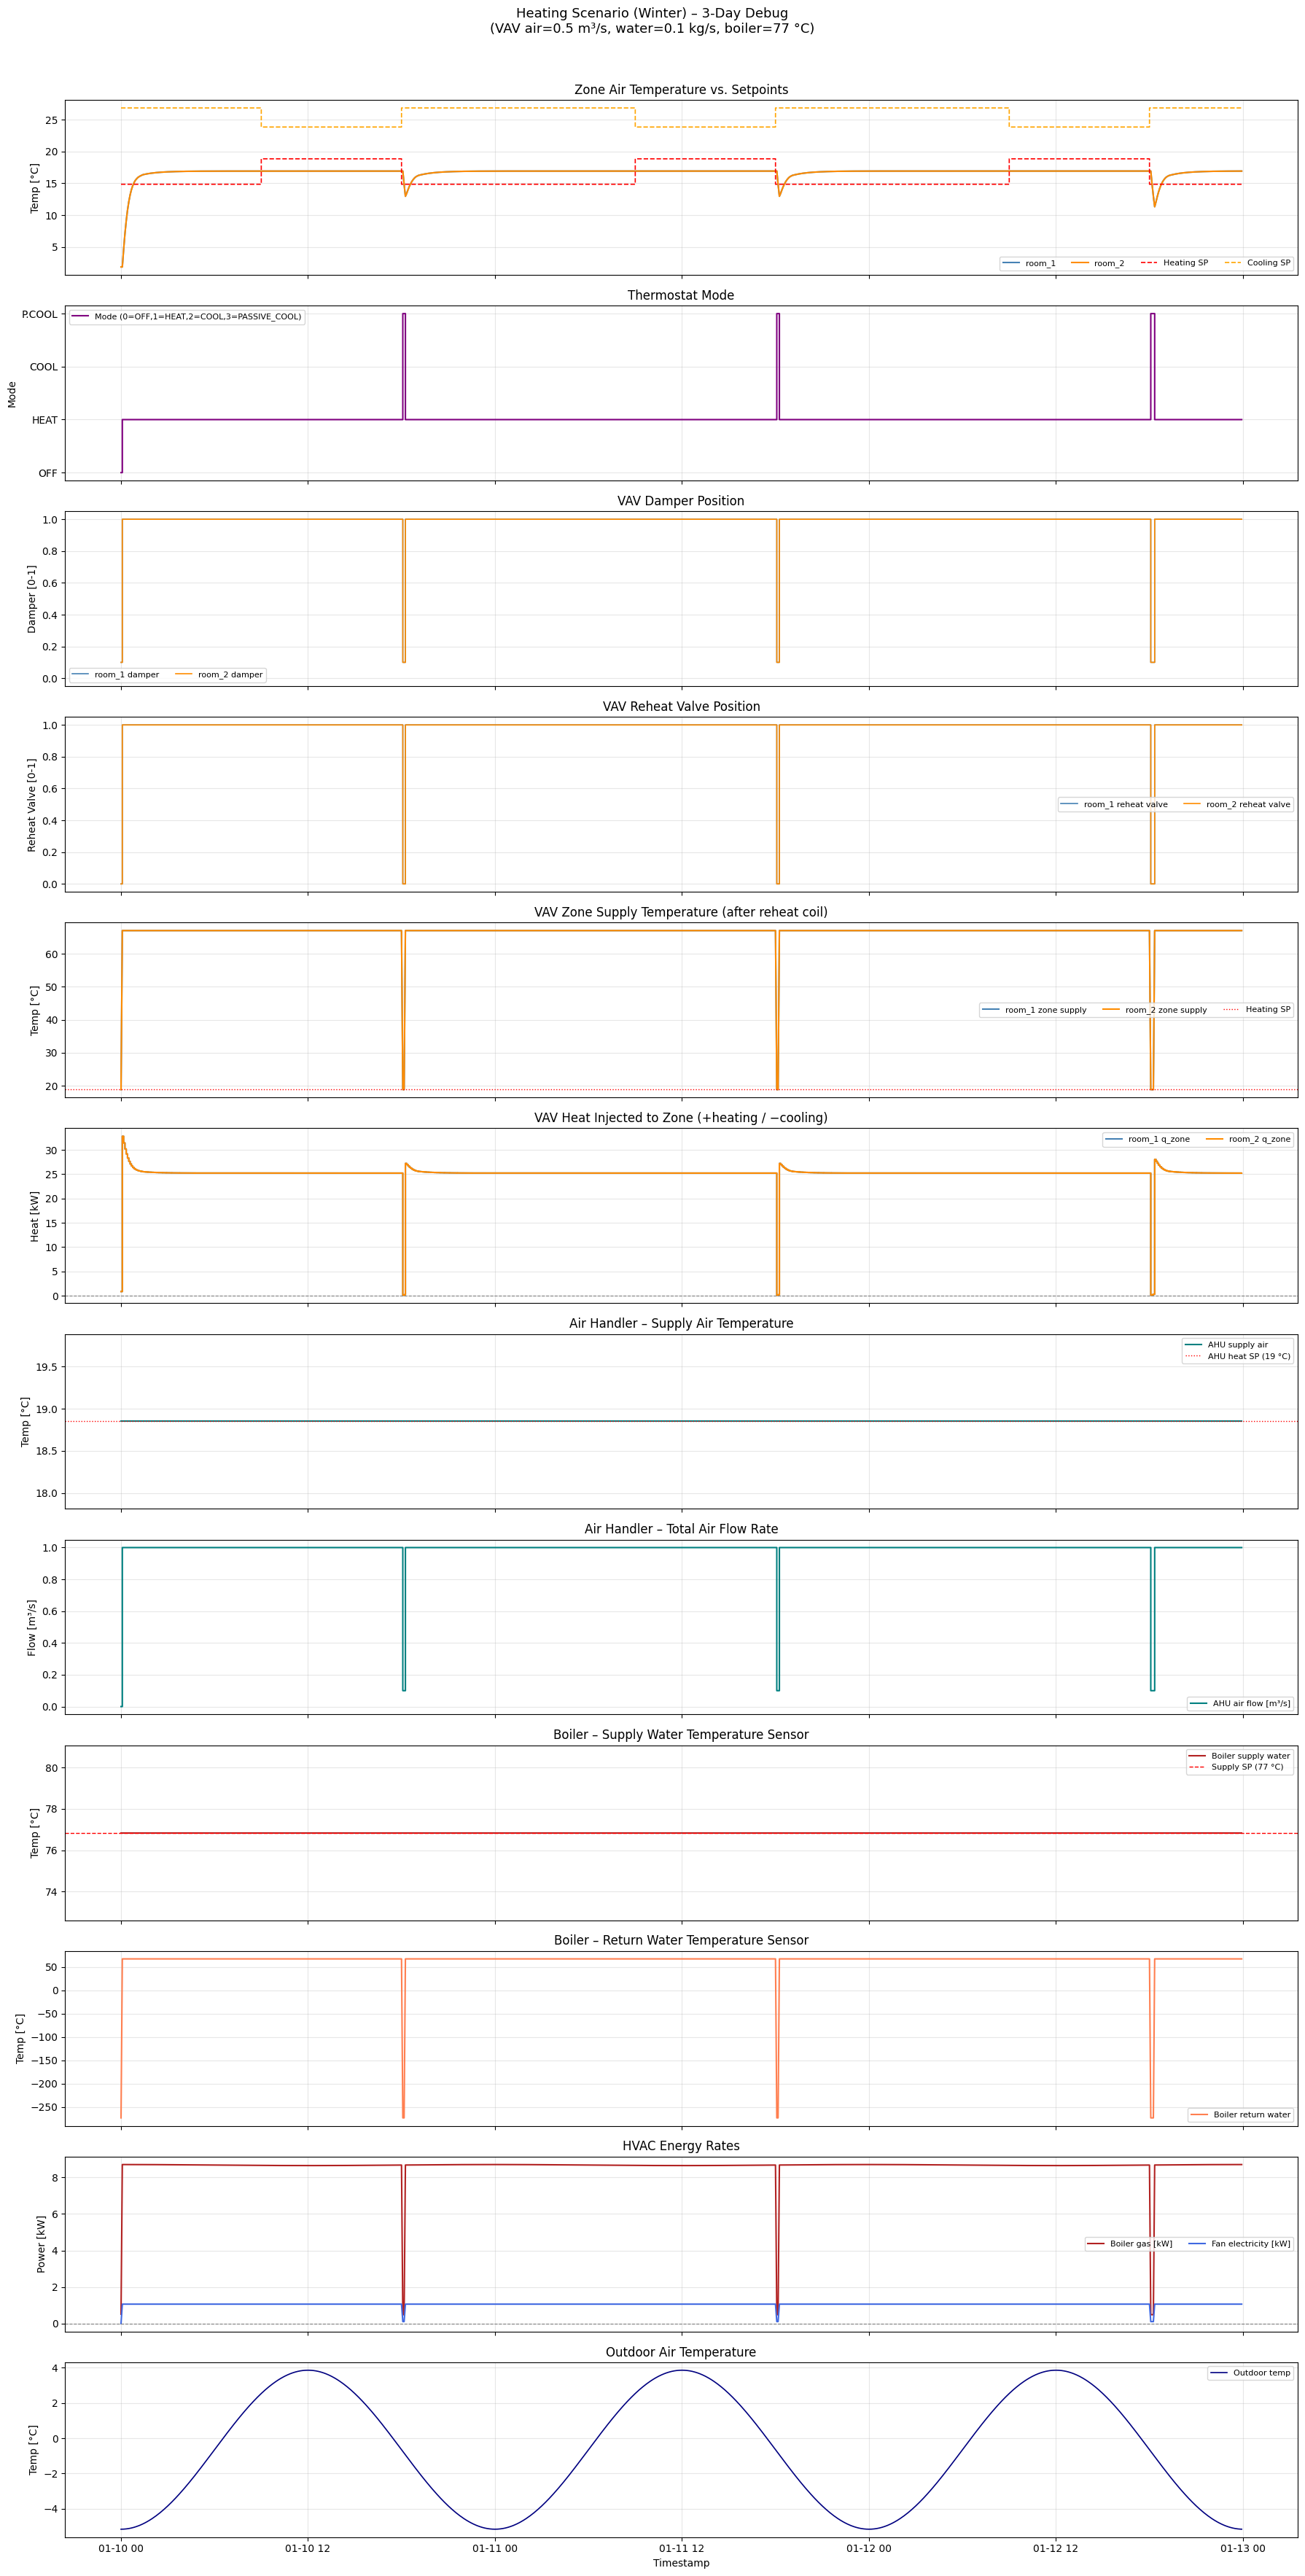

Heating debug figure complete.


In [10]:
ZONE_COLORS = {"room_1": "steelblue", "room_2": "darkorange"}
TS_H = ts_heat

N_ROWS = 12
fig_h, axes_h = plt.subplots(N_ROWS, 1, figsize=(18, N_ROWS * 3), sharex=True)
fig_h.suptitle(
    "Heating Scenario (Winter) – 3-Day Debug\n"
    f"(VAV air={VAV_MAX_AIR_FLOW} m³/s, water={VAV_MAX_WATER_FLOW} kg/s, "
    f"boiler={BOILER_SUPPLY_WATER_SP_K - KELVIN_TO_CELSIUS:.0f} °C)",
    fontsize=13,
)

# Row 0: Zone temperature vs. setpoints
ax = axes_h[0]
for zid in ZONE_IDS:
  ax.plot(TS_H, zone_temp_h[zid], color=ZONE_COLORS[zid], lw=1.5, label=zid)
ax.plot(
    TS_H,
    [t - KELVIN_TO_CELSIUS for t in h_sp_h],
    color="red",
    lw=1.2,
    ls="--",
    drawstyle="steps-post",
    label="Heating SP",
)
ax.plot(
    TS_H,
    [t - KELVIN_TO_CELSIUS for t in c_sp_h],
    color="orange",
    lw=1.2,
    ls="--",
    drawstyle="steps-post",
    label="Cooling SP",
)
ax.set_ylabel("Temp [°C]")
ax.set_title("Zone Air Temperature vs. Setpoints")
ax.legend(fontsize=8, ncol=4)
ax.grid(True, alpha=0.3)

# Row 1: Thermostat mode
ax = axes_h[1]
ax.plot(
    TS_H,
    mode_h,
    color="purple",
    lw=1.5,
    drawstyle="steps-post",
    label="Mode (0=OFF,1=HEAT,2=COOL,3=PASSIVE_COOL)",
)
ax.set_ylabel("Mode")
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(["OFF", "HEAT", "COOL", "P.COOL"])
ax.set_title("Thermostat Mode")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Row 2: VAV damper
ax = axes_h[2]
for zid in ZONE_IDS:
  ax.plot(
      TS_H,
      damper_h[zid],
      color=ZONE_COLORS[zid],
      lw=1.2,
      drawstyle="steps-post",
      label=f"{zid} damper",
  )
ax.set_ylabel("Damper [0-1]")
ax.set_ylim(-0.05, 1.05)
ax.set_title("VAV Damper Position")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# Row 3: VAV reheat valve
ax = axes_h[3]
for zid in ZONE_IDS:
  ax.plot(
      TS_H,
      reheat_v_h[zid],
      color=ZONE_COLORS[zid],
      lw=1.2,
      drawstyle="steps-post",
      label=f"{zid} reheat valve",
  )
ax.set_ylabel("Reheat Valve [0-1]")
ax.set_ylim(-0.05, 1.05)
ax.set_title("VAV Reheat Valve Position")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# Row 4: Zone supply temperature
ax = axes_h[4]
for zid in ZONE_IDS:
  ax.plot(
      TS_H,
      zone_supply_temp_h[zid],
      color=ZONE_COLORS[zid],
      lw=1.5,
      label=f"{zid} zone supply",
  )
ax.axhline(
    HEATING_SETPOINT_K - KELVIN_TO_CELSIUS,
    color="red",
    ls=":",
    lw=1,
    label="Heating SP",
)
ax.set_ylabel("Temp [°C]")
ax.set_title("VAV Zone Supply Temperature (after reheat coil)")
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)

# Row 5: Heat injected to zone (q_zone)
ax = axes_h[5]
for zid in ZONE_IDS:
  ax.plot(
      TS_H,
      q_zone_h[zid],
      color=ZONE_COLORS[zid],
      lw=1.5,
      drawstyle="steps-post",
      label=f"{zid} q_zone",
  )
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_ylabel("Heat [kW]")
ax.set_title("VAV Heat Injected to Zone (+heating / −cooling)")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# Row 6: AHU supply air temperature
ax = axes_h[6]
ax.plot(TS_H, ahu_supply_h, color="teal", lw=1.5, label="AHU supply air")
ax.axhline(
    AHU_HEAT_SP_K - KELVIN_TO_CELSIUS,
    color="red",
    ls=":",
    lw=1,
    label=f"AHU heat SP ({AHU_HEAT_SP_K - KELVIN_TO_CELSIUS:.0f} °C)",
)
ax.set_ylabel("Temp [°C]")
ax.set_title("Air Handler – Supply Air Temperature")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Row 7: AHU air flow rate
ax = axes_h[7]
ax.plot(
    TS_H,
    ahu_flow_h,
    color="teal",
    lw=1.5,
    drawstyle="steps-post",
    label="AHU air flow [m³/s]",
)
ax.set_ylabel("Flow [m³/s]")
ax.set_title("Air Handler – Total Air Flow Rate")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Row 8: Boiler supply water temperature
ax = axes_h[8]
ax.plot(
    TS_H, boiler_sw_h, color="firebrick", lw=1.5, label="Boiler supply water"
)
ax.axhline(
    BOILER_SUPPLY_WATER_SP_K - KELVIN_TO_CELSIUS,
    color="red",
    ls="--",
    lw=1,
    label=f"Supply SP ({BOILER_SUPPLY_WATER_SP_K - KELVIN_TO_CELSIUS:.0f} °C)",
)
ax.set_ylabel("Temp [°C]")
ax.set_title("Boiler – Supply Water Temperature Sensor")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Row 9: Boiler return water temperature
ax = axes_h[9]
ax.plot(TS_H, boiler_rw_h, color="coral", lw=1.5, label="Boiler return water")
ax.set_ylabel("Temp [°C]")
ax.set_title("Boiler – Return Water Temperature Sensor")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Row 10: HVAC energy rates
ax = axes_h[10]
ax.plot(TS_H, boiler_gas_h, color="firebrick", lw=1.5, label="Boiler gas [kW]")
ax.plot(
    TS_H, fan_elec_h, color="royalblue", lw=1.5, label="Fan electricity [kW]"
)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_ylabel("Power [kW]")
ax.set_title("HVAC Energy Rates")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# Row 11: Outdoor air temperature
ax = axes_h[11]
ax.plot(TS_H, outdoor_h, color="navy", lw=1.2, label="Outdoor temp")
ax.set_ylabel("Temp [°C]")
ax.set_xlabel("Timestamp")
ax.set_title("Outdoor Air Temperature")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
print("Heating debug figure complete.")

## Section 8 – TFSimulator: Cooling Scenario (3-day)

In [ ]:
INITIAL_TEMP_COOLING = 310.0
START_TS_SUMMER = pd.Timestamp("2024-07-15 00:00:00")

bld_cool = create_building(INITIAL_TEMP_COOLING)
hvac_cool = create_hvac(sorted(bld_cool.get_zone_average_temps()))

sim_cool = tf_simulator_py.TFSimulator(
    building=bld_cool,
    hvac=hvac_cool,
    weather_controller=wc_summer,
    time_step_sec=TIME_STEP_SEC,
    convergence_threshold=0.1,
    iteration_limit=100,
    iteration_warning=10,
    start_timestamp=START_TS_SUMMER,
)

print(
    "TFSimulator COOLING init. Mean zone T = "
    f"{bld_cool.temp.mean() - KELVIN_TO_CELSIUS:.2f} °C"
)

ts_cool = []
zone_temp_c = {z: [] for z in ZONE_IDS}
h_sp_c_list, c_sp_c_list, mode_c = [], [], []
damper_c = {z: [] for z in ZONE_IDS}
reheat_v_c = {z: [] for z in ZONE_IDS}
zone_supply_temp_c = {z: [] for z in ZONE_IDS}
q_zone_c = {z: [] for z in ZONE_IDS}
ahu_supply_c = []
ahu_flow_c = []
boiler_sw_c = []
boiler_rw_c = []
boiler_gas_c = []
fan_elec_c = []
outdoor_c = []

for step in range(N_STEPS):
  ts = sim_cool.current_timestamp
  outdoor_k = wc_summer.get_current_temp(ts)
  rec_temp = bld_cool.temp.mean()
  ahu_supply_k = hvac_cool.air_handler.get_supply_air_temp(rec_temp, outdoor_k)

  ts_cool.append(ts)
  sched = hvac_cool.vavs[REF_ZONE].thermostat.get_setpoint_schedule()
  h_sp, c_sp = sched.get_temperature_window(ts)
  h_sp_c_list.append(h_sp)
  c_sp_c_list.append(c_sp)
  # pylint: disable=protected-access
  mode_c.append(hvac_cool.vavs[REF_ZONE].thermostat._current_mode.value)
  # pylint: enable=protected-access

  zone_avgs = bld_cool.get_zone_average_temps()
  for zid in ZONE_IDS:
    zone_temp_c[zid].append(zone_avgs[zid] - KELVIN_TO_CELSIUS)
    damper_c[zid].append(hvac_cool.vavs[zid].damper_setting)
    reheat_v_c[zid].append(hvac_cool.vavs[zid].reheat_valve_setting)
    zst_k = hvac_cool.vavs[zid].compute_zone_supply_temp(
        ahu_supply_k, hvac_cool.boiler.reheat_water_setpoint
    )
    zone_supply_temp_c[zid].append(zst_k - KELVIN_TO_CELSIUS)
    q_w = hvac_cool.vavs[zid].compute_energy_applied_to_zone(
        zone_avgs[zid], ahu_supply_k, hvac_cool.boiler.reheat_water_setpoint
    )
    q_zone_c[zid].append(q_w / 1000)

  ahu_supply_c.append(ahu_supply_k - KELVIN_TO_CELSIUS)
  ahu_flow_c.append(hvac_cool.air_handler.air_flow_rate)

  rw_k = hvac_cool.boiler.return_water_temperature_sensor
  boiler_sw_c.append(
      hvac_cool.boiler.supply_water_temperature_sensor - KELVIN_TO_CELSIUS
  )
  boiler_rw_c.append(rw_k - KELVIN_TO_CELSIUS)
  boiler_gas_c.append(
      hvac_cool.boiler.compute_thermal_energy_rate(rw_k, outdoor_k) / 1000
  )
  fan_elec_c.append(
      (
          hvac_cool.air_handler.compute_intake_fan_energy_rate()
          + hvac_cool.air_handler.compute_exhaust_fan_energy_rate()
      )
      / 1000
  )
  outdoor_c.append(outdoor_k - KELVIN_TO_CELSIUS)

  sim_cool.step_sim()

  if (step + 1) % 288 == 0:
    avg_t = sum(bld_cool.get_zone_average_temps().values()) / len(ZONE_IDS)
    print(
        f'  Day {(step+1)//288} | {ts.strftime("%m-%d %H:%M")}'
        f" | mean T={avg_t - KELVIN_TO_CELSIUS:.2f} °C"
        f" | outdoor={outdoor_k - KELVIN_TO_CELSIUS:.2f} °C"
        f" | mode={mode_c[-1]}"
    )

print("Cooling simulation complete.")

## Section 9 – Cooling Scenario: 12-Row Debug Visualisation

In [ ]:
TS_C = ts_cool
fig_c, axes_c = plt.subplots(N_ROWS, 1, figsize=(18, N_ROWS * 3), sharex=True)
fig_c.suptitle(
    "Cooling Scenario (Summer) – 3-Day Debug\n"
    f"(VAV air={VAV_MAX_AIR_FLOW} m³/s, AHU cool SP="
    f"{AHU_COOL_SP_K - KELVIN_TO_CELSIUS:.0f} °C)",
    fontsize=13,
)

ax = axes_c[0]
for zid in ZONE_IDS:
  ax.plot(TS_C, zone_temp_c[zid], color=ZONE_COLORS[zid], lw=1.5, label=zid)
ax.plot(
    TS_C,
    [t - KELVIN_TO_CELSIUS for t in h_sp_c_list],
    color="red",
    lw=1.2,
    ls="--",
    drawstyle="steps-post",
    label="Heating SP",
)
ax.plot(
    TS_C,
    [t - KELVIN_TO_CELSIUS for t in c_sp_c_list],
    color="orange",
    lw=1.2,
    ls="--",
    drawstyle="steps-post",
    label="Cooling SP",
)
ax.set_ylabel("Temp [°C]")
ax.set_title("Zone Air Temperature vs. Setpoints")
ax.legend(fontsize=8, ncol=4, loc="upper right")
ax.grid(True, alpha=0.3)

ax = axes_c[1]
ax.plot(
    TS_C,
    mode_c,
    color="purple",
    lw=1.5,
    drawstyle="steps-post",
    label="Mode (0=OFF,1=HEAT,2=COOL,3=PASSIVE_COOL)",
)
ax.set_ylabel("Mode")
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(["OFF", "HEAT", "COOL", "P.COOL"])
ax.set_title("Thermostat Mode")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes_c[2]
for zid in ZONE_IDS:
  ax.plot(
      TS_C,
      damper_c[zid],
      color=ZONE_COLORS[zid],
      lw=1.2,
      drawstyle="steps-post",
      label=f"{zid} damper",
  )
ax.set_ylabel("Damper [0-1]")
ax.set_ylim(-0.05, 1.05)
ax.set_title("VAV Damper Position")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

ax = axes_c[3]
for zid in ZONE_IDS:
  ax.plot(
      TS_C,
      reheat_v_c[zid],
      color=ZONE_COLORS[zid],
      lw=1.2,
      drawstyle="steps-post",
      label=f"{zid} reheat valve",
  )
ax.set_ylabel("Reheat Valve [0-1]")
ax.set_ylim(-0.05, 1.05)
ax.set_title("VAV Reheat Valve Position")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

ax = axes_c[4]
for zid in ZONE_IDS:
  ax.plot(
      TS_C,
      zone_supply_temp_c[zid],
      color=ZONE_COLORS[zid],
      lw=1.5,
      label=f"{zid} zone supply",
  )
ax.axhline(
    COOLING_SETPOINT_K - KELVIN_TO_CELSIUS,
    color="orange",
    ls=":",
    lw=1,
    label="Cooling SP",
)
ax.set_ylabel("Temp [°C]")
ax.set_title("VAV Zone Supply Temperature (after reheat coil)")
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)

ax = axes_c[5]
for zid in ZONE_IDS:
  ax.plot(
      TS_C,
      q_zone_c[zid],
      color=ZONE_COLORS[zid],
      lw=1.5,
      drawstyle="steps-post",
      label=f"{zid} q_zone",
  )
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_ylabel("Heat [kW]")
ax.set_title("VAV Heat Injected to Zone (negative = cooling)")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

ax = axes_c[6]
ax.plot(TS_C, ahu_supply_c, color="teal", lw=1.5, label="AHU supply air")
ax.axhline(
    AHU_COOL_SP_K - KELVIN_TO_CELSIUS,
    color="orange",
    ls=":",
    lw=1,
    label=f"AHU cool SP ({AHU_COOL_SP_K - KELVIN_TO_CELSIUS:.0f} °C)",
)
ax.set_ylabel("Temp [°C]")
ax.set_title("Air Handler – Supply Air Temperature")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes_c[7]
ax.plot(
    TS_C,
    ahu_flow_c,
    color="teal",
    lw=1.5,
    drawstyle="steps-post",
    label="AHU air flow [m³/s]",
)
ax.set_ylabel("Flow [m³/s]")
ax.set_title("Air Handler – Total Air Flow Rate")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes_c[8]
ax.plot(
    TS_C, boiler_sw_c, color="firebrick", lw=1.5, label="Boiler supply water"
)
ax.axhline(
    BOILER_SUPPLY_WATER_SP_K - KELVIN_TO_CELSIUS,
    color="red",
    ls="--",
    lw=1,
    label=f"Supply SP ({BOILER_SUPPLY_WATER_SP_K - KELVIN_TO_CELSIUS:.0f} °C)",
)
ax.set_ylabel("Temp [°C]")
ax.set_title("Boiler – Supply Water Temperature Sensor")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes_c[9]
ax.plot(TS_C, boiler_rw_c, color="coral", lw=1.5, label="Boiler return water")
ax.set_ylabel("Temp [°C]")
ax.set_title("Boiler – Return Water Temperature Sensor")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes_c[10]
ax.plot(TS_C, boiler_gas_c, color="firebrick", lw=1.5, label="Boiler gas [kW]")
ax.plot(
    TS_C, fan_elec_c, color="royalblue", lw=1.5, label="Fan electricity [kW]"
)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_ylabel("Power [kW]")
ax.set_title("HVAC Energy Rates")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

ax = axes_c[11]
ax.plot(TS_C, outdoor_c, color="saddlebrown", lw=1.2, label="Outdoor temp")
ax.set_ylabel("Temp [°C]")
ax.set_xlabel("Timestamp")
ax.set_title("Outdoor Air Temperature")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
print("Cooling debug figure complete.")

## Section 10 – Scenario Comparison (4-row overlay)

In [ ]:
def to_hours(ts_list, t0):
  return [(t - t0).total_seconds() / 3600 for t in ts_list]


hours_h = to_hours(ts_heat, ts_heat[0])
hours_c = to_hours(ts_cool, ts_cool[0])

fig_cmp, axes_cmp = plt.subplots(4, 1, figsize=(16, 16), sharex=True)
fig_cmp.suptitle(
    f"Heating vs. Cooling – Overlaid (0–{N_DAYS*24} h)", fontsize=13
)

ax = axes_cmp[0]
for zid in ZONE_IDS:
  ax.plot(
      hours_h,
      zone_temp_h[zid],
      color=ZONE_COLORS[zid],
      lw=1.5,
      ls="-",
      label=f"{zid} (heat)",
  )
  ax.plot(
      hours_c,
      zone_temp_c[zid],
      color=ZONE_COLORS[zid],
      lw=1.5,
      ls="--",
      label=f"{zid} (cool)",
  )
ax.axhline(h_sp_c, color="red", ls=":", lw=1, label=f"HeatSP {h_sp_c:.0f} °C")
ax.axhline(
    c_sp_c, color="orange", ls=":", lw=1, label=f"CoolSP {c_sp_c:.0f} °C"
)
ax.set_ylabel("Temp [°C]")
ax.set_title("Zone Air Temperatures")
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)

ax = axes_cmp[1]
for zid in ZONE_IDS:
  ax.plot(
      hours_h,
      zone_supply_temp_h[zid],
      color=ZONE_COLORS[zid],
      lw=1.5,
      ls="-",
      label=f"{zid} supply (heat)",
  )
  ax.plot(
      hours_c,
      zone_supply_temp_c[zid],
      color=ZONE_COLORS[zid],
      lw=1.5,
      ls="--",
      label=f"{zid} supply (cool)",
  )
ax.set_ylabel("Temp [°C]")
ax.set_title("VAV Zone Supply Temperature")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

ax = axes_cmp[2]
for zid in ZONE_IDS:
  ax.plot(
      hours_h,
      q_zone_h[zid],
      color=ZONE_COLORS[zid],
      lw=1.5,
      ls="-",
      drawstyle="steps-post",
      label=f"{zid} q (heat)",
  )
  ax.plot(
      hours_c,
      q_zone_c[zid],
      color=ZONE_COLORS[zid],
      lw=1.5,
      ls="--",
      drawstyle="steps-post",
      label=f"{zid} q (cool)",
  )
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_ylabel("Heat [kW]")
ax.set_title("Heat Injected to Zone")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

ax = axes_cmp[3]
ax.plot(
    hours_h,
    boiler_gas_h,
    color="firebrick",
    lw=1.5,
    label="Boiler gas (heat) [kW]",
)
ax.plot(
    hours_c,
    boiler_gas_c,
    color="firebrick",
    lw=1.5,
    ls="--",
    label="Boiler gas (cool) [kW]",
)
ax.plot(
    hours_h,
    fan_elec_h,
    color="royalblue",
    lw=1.5,
    label="Fan elec (heat) [kW]",
)
ax.plot(
    hours_c,
    fan_elec_c,
    color="royalblue",
    lw=1.5,
    ls="--",
    label="Fan elec (cool) [kW]",
)
ax.set_ylabel("Power [kW]")
ax.set_xlabel("Hours from start")
ax.set_title("HVAC Energy Rates")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
print("Comparison figure complete.")

## Section 11 – Summary

In [ ]:
DT_H = TIME_STEP_SEC / 3600


def scenario_summary(
    scenario_label, zone_temps_c, h_sp_k_list, c_sp_k_list, gas_list, fan_list
):
  """Return a dict of summary metrics."""
  all_temps = []
  for zone_key in ZONE_IDS:
    all_temps.extend(zone_temps_c[zone_key])
  total_gas_kwh = sum(gas_list) * DT_H
  total_fan_kwh = sum(fan_list) * DT_H
  in_comfort = [
      (zone_temps_c[zid][i] >= h_sp_k_list[i] - KELVIN_TO_CELSIUS)
      and (zone_temps_c[zid][i] <= c_sp_k_list[i] - KELVIN_TO_CELSIUS)
      for i in range(len(h_sp_k_list))
      for zid in ZONE_IDS
  ]
  return {
      "Scenario": scenario_label,
      "Min zone temp [C]": round(min(all_temps), 2),
      "Max zone temp [C]": round(max(all_temps), 2),
      "% Time in comfort": round(sum(in_comfort) / len(in_comfort) * 100, 1),
      "Boiler gas [kWh]": round(total_gas_kwh, 1),
      "Fan elec [kWh]": round(total_fan_kwh, 2),
      "Total HVAC [kWh]": round(total_gas_kwh + total_fan_kwh, 1),
  }


smry_h = scenario_summary(
    "Winter Heating", zone_temp_h, h_sp_h, c_sp_h, boiler_gas_h, fan_elec_h
)
smry_c = scenario_summary(
    "Summer Cooling",
    zone_temp_c,
    h_sp_c_list,
    c_sp_c_list,
    boiler_gas_c,
    fan_elec_c,
)

smry_df = pd.DataFrame([smry_h, smry_c]).set_index("Scenario")
print("=" * 65)
print("SIMULATION SUMMARY")
print("=" * 65)
print(smry_df.to_string())
print()
print("Notebook complete.")